In [44]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import copy
import itertools

In [45]:
file_path = "dataset_ovarian_cancer.txt"

df = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=5
)

print(df.head())
print()
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns)

  Sample-ID  Replicate     PROK1       WFDC2        KRT19    FR-alpha  \
0      id_1          1  51.27954  2684.67462  814977.3242   978.62687   
1      id_1          2  61.33529  2837.46526  896027.9581  1105.94503   
2      id_2          1  24.85198  2330.02736  791045.9677   839.24954   
3      id_2          2  40.97260  2827.01105  1003158.814  1037.14645   
4      id_3          1  26.02276  2398.98013  1193382.307  1045.50094   

       ICOSLG         CDH3        MSMB    CLEC6A    TACSTD2       MUC-16  \
0  4962.66112  38555.25779  4923.13477  15.18093  160.80636  16652.85209   
1  5416.43019  39359.37085  4895.63176  14.14949  161.81711  17377.84122   
2  5625.48669  30198.26938  4453.04688  12.05641  130.42806   30700.9644   
3  7302.93771  34436.35092  5443.09544  15.06589  153.65555  43507.23046   
4  5224.95801  20999.56857  5890.22654   7.07682  172.29628  28569.18683   

       SPINT1  AgeAtDiag Diagnosis  
0  9610.23806         49         I  
1   8858.6119         49      

In [46]:
features = [
    "PROK1",
    "WFDC2",
    "KRT19",
    "FR-alpha",
    "ICOSLG",
    "CDH3",
    "MSMB",
    "CLEC6A",
    "TACSTD2",
    "MUC-16",
    "SPINT1",
    "AgeAtDiag"
]

target = "Diagnosis"

uloq = {
    "PROK1": 16883.06305,
    "WFDC2": 181210.6285,
    "KRT19": 68900244.48,
    "FR-alpha": 163421.4035,
    "ICOSLG": 55648.31473,
    "CDH3": 638185.7656,
    "MSMB": 177291.4083,
    "CLEC6A": 13291.04962,
    "TACSTD2": 33922.31855,
    "MUC-16": 2288168.669,
    "SPINT1": 193069.9522
}

for feature in uloq:
    df[feature] = df[feature].replace(
        "> ULOQ",
        uloq[feature]
    )

    df[feature] = pd.to_numeric(
        df[feature],
        errors="coerce"
    )

print("Missing values:")
print(df[features].isna().sum())

Missing values:
PROK1        7
WFDC2        7
KRT19        7
FR-alpha     7
ICOSLG       7
CDH3         7
MSMB         7
CLEC6A       7
TACSTD2      7
MUC-16       7
SPINT1       7
AgeAtDiag    0
dtype: int64


In [47]:
df_patient = (
    df.groupby("Sample-ID")
      .agg({
          **{feature: "mean" for feature in features},
          "Diagnosis": "first"
      })
      .reset_index()
)

print("Patient-level dataset:")
print(df_patient.head())

print()
print("Shape:", df_patient.shape)

Patient-level dataset:
  Sample-ID       PROK1        WFDC2         KRT19     FR-alpha       ICOSLG  \
0      id_1   56.307415  2761.069940  8.555026e+05  1042.285950  5189.545655   
1     id_10   60.051290  2692.821970  7.599913e+05   911.213855  5974.368245   
2    id_100   70.799593  2208.716773  6.956947e+05   866.758660  6208.133080   
3    id_101   55.791713  2176.080353  1.006915e+06   829.835973  4927.174610   
4    id_102  158.137193  3138.790933  9.798309e+05   891.867067  4373.818200   

            CDH3         MSMB     CLEC6A     TACSTD2         MUC-16  \
0   38957.314320  4909.383265  14.665210  161.311735   17015.346655   
1   28535.242535  1702.930035   9.942800  192.346485    3963.833860   
2   43719.793630  3900.999347  14.356180  189.454073  109807.330633   
3   28681.659173  3558.996607  13.050203  101.552563   15534.116423   
4  184746.854733  3592.575700   7.482760  158.556143   54909.897717   

         SPINT1  AgeAtDiag   Diagnosis  
0   9234.424980       49.0  

In [48]:
X = df_patient[features].copy()
y = df_patient[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

X shape: (224, 12)
y shape: (224,)
Classes:
['I' 'II' 'III' 'IV' 'benign' 'borderline']


In [49]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (156, 12)
Validation: (34, 12)
Test: (34, 12)


In [50]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)

X_val = imputer.transform(X_val)

X_test = imputer.transform(X_test)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [51]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [52]:
batch_size = 16

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [41]:
print("Train:", X_train_tensor.shape)
print("Validation:", X_val_tensor.shape)
print("Test:", X_test_tensor.shape)

print()

print("Example X:")
print(X_train_tensor[0])

print()

print("Example y:")
print(y_train_tensor[0])

print()

print("Classes:")
print(label_encoder.classes_)

Train: torch.Size([156, 12])
Validation: torch.Size([34, 12])
Test: torch.Size([34, 12])

Example X:
tensor([ 7.3616, -0.5484, -0.3669, -0.2711, -0.3894, -0.5102, -0.4278, -0.7111,
        -0.4575, -0.5569, -0.1329, -1.4606])

Example y:
tensor(5)

Classes:
['I' 'II' 'III' 'IV' 'benign' 'borderline']


In [42]:
#MLP

class MLP(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [53]:
# ONN OPERATOR LIBRARIES

# NODAL

def clamp(x, limit):
    return torch.clamp(x, -limit, limit)

NODAL_OPERATORS = {

    "linear":
        lambda x: x,

    "quadratic":
        lambda x: torch.sign(x) * clamp(x, 4.0) ** 2,

    "cubic":
        lambda x: clamp(x, 3.0) ** 3,

    "sinusoidal":
        lambda x: torch.sin(x),

    "tanh":
        lambda x: torch.tanh(x),

    "gaussian":
        lambda x: torch.exp(-clamp(x, 4.0) ** 2),

    "dog":
        lambda x: clamp(x, 4.0) *
                  torch.exp(-clamp(x, 4.0) ** 2),

    "exponential":
        lambda x: torch.sign(x) *
                  (torch.exp(clamp(torch.abs(x), 4.0)) - 1.0)
}

# POOLING

def pool_sum(x):
    return x.sum(dim=2)


def pool_mean(x):
    return x.mean(dim=2)


def pool_max(x):
    return x.max(dim=2).values


def pool_min(x):
    return x.min(dim=2).values


def pool_l2(x):
    return torch.sqrt(
        torch.sum(x ** 2, dim=2) + 1e-8
    )

POOLING_OPERATORS = {

    "sum": pool_sum,

    "mean": pool_mean,

    "max": pool_max,

    "min": pool_min,

    "l2": pool_l2
}

In [ ]:
# OPERATIONAL LAYER

class OperationalLayer(nn.Module):

    def __init__(
        self,
        in_features,
        out_features,
        nodal_operator="linear",
        pooling_operator="sum"
    ):

        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        self.nodal_operator_name = nodal_operator
        self.pooling_operator_name = pooling_operator

        # Weight for every connection
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features)
            * np.sqrt(2.0 / in_features)
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

    def forward(self, x):

        z = (
            x.unsqueeze(1)
            * self.weight.unsqueeze(0)
        )

        # NODAL

        nodal_operator = NODAL_OPERATORS[
            self.nodal_operator_name
        ]

        z = nodal_operator(z)

        # POOLING

        pooling_operator = POOLING_OPERATORS[
            self.pooling_operator_name
        ]

        y = pooling_operator(z)

        # BIAS

        y = y + self.bias

        return y

In [55]:
# ONN MODEL

class ONN(nn.Module):

    def __init__(
        self,
        input_size,
        num_classes,
        hidden_sizes=(32, 16),
        nodal_operators=("linear", "linear"),
        pooling_operators=("sum", "sum"),
        dropout=0.2
    ):

        super().__init__()

        assert len(nodal_operators) == len(hidden_sizes)
        assert len(pooling_operators) == len(hidden_sizes)

        dims = [
            input_size,
            *hidden_sizes,
            num_classes
        ]

        self.hidden_layers = nn.ModuleList()

        self.dropouts = nn.ModuleList()

        # HIDDEN

        for i in range(len(hidden_sizes)):

            layer = OperationalLayer(
                in_features=dims[i],
                out_features=dims[i + 1],
                nodal_operator=nodal_operators[i],
                pooling_operator=pooling_operators[i]
            )

            self.hidden_layers.append(layer)

            self.dropouts.append(
                nn.Dropout(dropout)
            )

        # OUTPUT

        self.output_layer = OperationalLayer(
            in_features=dims[-2],
            out_features=num_classes,
            nodal_operator="linear",
            pooling_operator="sum"
        )

    def forward(self, x):

        for layer, dropout in zip(
            self.hidden_layers,
            self.dropouts
        ):

            x = layer(x)

            x = dropout(x)

        x = self.output_layer(x)

        return x

In [56]:
# ============================================================
# TEST ONN LAYER
# ============================================================

test_layer = OperationalLayer(
    in_features=12,
    out_features=32,
    nodal_operator="sinusoidal",
    pooling_operator="mean"
)

x_test = torch.randn(8, 12)

output = test_layer(x_test)

print("Input shape:")
print(x_test.shape)

print()

print("Output shape:")
print(output.shape)

Input shape:
torch.Size([8, 12])

Output shape:
torch.Size([8, 32])


In [57]:
# ============================================================
# TRAIN ONE ONN CONFIGURATION
# ============================================================

def train_eval_onn(
    nodal_operators,
    pooling_operators,
    input_size,
    num_classes,
    train_loader,
    val_loader,
    device,
    epochs=60,
    learning_rate=0.001,
    weight_decay=1e-4,
    hidden_sizes=(32, 16),
    dropout=0.2
):

    model = ONN(
        input_size=input_size,
        num_classes=num_classes,
        hidden_sizes=hidden_sizes,
        nodal_operators=nodal_operators,
        pooling_operators=pooling_operators,
        dropout=dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_val_accuracy = 0.0
    best_state = None

    for epoch in range(epochs):

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                predictions = outputs.argmax(dim=1)

                correct += (
                    predictions == y_batch
                ).sum().item()

                total += y_batch.size(0)

        val_accuracy = correct / total

        # ----------------------------------------------------
        # SAVE BEST MODEL
        # ----------------------------------------------------

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            best_state = copy.deepcopy(
                model.state_dict()
            )

    # Restore best validation model

    if best_state is not None:

        model.load_state_dict(best_state)

    return model, best_val_accuracy

In [58]:
# ============================================================
# GIS
# GREEDY OPERATOR SELECTION
# ============================================================

def GIS(
    input_size,
    num_classes,
    train_loader,
    val_loader,
    device,
    hidden_sizes=(32, 16),
    epochs=60,
    dropout=0.2
):

    selected_nodal = []
    selected_pooling = []

    num_layers = len(hidden_sizes)

    print("=" * 60)
    print("STARTING GIS")
    print("=" * 60)

    # --------------------------------------------------------
    # Search one layer at a time
    # --------------------------------------------------------

    for layer_idx in range(num_layers):

        print()
        print(
            f"Searching layer "
            f"{layer_idx + 1}/{num_layers}"
        )

        best_score = -float("inf")

        best_nodal = None
        best_pooling = None

        # ----------------------------------------------------
        # Try every nodal + pooling combination
        # ----------------------------------------------------

        for nodal_name in NODAL_OPERATORS.keys():

            for pooling_name in POOLING_OPERATORS.keys():

                # Operators already selected for previous layers
                trial_nodal = selected_nodal + [
                    nodal_name
                ]

                trial_pooling = selected_pooling + [
                    pooling_name
                ]

                # ------------------------------------------------
                # Remaining layers use linear + sum
                # ------------------------------------------------

                while len(trial_nodal) < num_layers:

                    trial_nodal.append("linear")
                    trial_pooling.append("sum")

                print(
                    f"Testing: "
                    f"Layer {layer_idx + 1} → "
                    f"nodal={nodal_name}, "
                    f"pooling={pooling_name}"
                )

                model, val_accuracy = train_eval_onn(
                    nodal_operators=trial_nodal,
                    pooling_operators=trial_pooling,
                    input_size=input_size,
                    num_classes=num_classes,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    device=device,
                    epochs=epochs,
                    hidden_sizes=hidden_sizes,
                    dropout=dropout
                )

                print(
                    f"Validation accuracy: "
                    f"{val_accuracy:.4f}"
                )

                # ------------------------------------------------
                # Keep best combination
                # ------------------------------------------------

                if val_accuracy > best_score:

                    best_score = val_accuracy

                    best_nodal = nodal_name
                    best_pooling = pooling_name

        # ----------------------------------------------------
        # Permanently select best operators for this layer
        # ----------------------------------------------------

        selected_nodal.append(best_nodal)
        selected_pooling.append(best_pooling)

        print()
        print(
            f"BEST FOR LAYER {layer_idx + 1}:"
        )

        print(
            f"  Nodal   = {best_nodal}"
        )

        print(
            f"  Pooling = {best_pooling}"
        )

        print(
            f"  Validation accuracy = "
            f"{best_score:.4f}"
        )

    # --------------------------------------------------------
    # Final architecture
    # --------------------------------------------------------

    print()
    print("=" * 60)
    print("GIS RESULT")
    print("=" * 60)

    for i in range(num_layers):

        print(
            f"Layer {i + 1}: "
            f"nodal={selected_nodal[i]}, "
            f"pooling={selected_pooling[i]}"
        )

    return selected_nodal, selected_pooling

In [59]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ============================================================
# RUN GIS
# ============================================================

selected_nodal, selected_pooling = GIS(
    input_size=input_size,
    num_classes=num_classes,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,

    # Smaller network is preferable for your dataset
    hidden_sizes=(32, 16),

    # GIS training epochs
    epochs=60,

    dropout=0.2
)



Device: cpu
STARTING GIS

Searching layer 1/2
Testing: Layer 1 → nodal=linear, pooling=sum
Validation accuracy: 0.5294
Testing: Layer 1 → nodal=linear, pooling=mean
Validation accuracy: 0.5882
Testing: Layer 1 → nodal=linear, pooling=max
Validation accuracy: 0.5588
Testing: Layer 1 → nodal=linear, pooling=min
Validation accuracy: 0.5588
Testing: Layer 1 → nodal=linear, pooling=l2
Validation accuracy: 0.5588
Testing: Layer 1 → nodal=quadratic, pooling=sum
Validation accuracy: 0.5294
Testing: Layer 1 → nodal=quadratic, pooling=mean
Validation accuracy: 0.5294
Testing: Layer 1 → nodal=quadratic, pooling=max
Validation accuracy: 0.5294
Testing: Layer 1 → nodal=quadratic, pooling=min
Validation accuracy: 0.5882
Testing: Layer 1 → nodal=quadratic, pooling=l2
Validation accuracy: 0.5588
Testing: Layer 1 → nodal=cubic, pooling=sum
Validation accuracy: 0.4706
Testing: Layer 1 → nodal=cubic, pooling=mean
Validation accuracy: 0.5588
Testing: Layer 1 → nodal=cubic, pooling=max
Validation accuracy:

In [60]:
# ============================================================
# FINAL GIS-SELECTED ONN
# ============================================================

onn_model = ONN(
    input_size=input_size,
    num_classes=num_classes,

    hidden_sizes=(32, 16),

    nodal_operators=selected_nodal,

    pooling_operators=selected_pooling,

    dropout=0.2
).to(device)

print(onn_model)

ONN(
  (hidden_layers): ModuleList(
    (0-1): 2 x OperationalLayer()
  )
  (dropouts): ModuleList(
    (0-1): 2 x Dropout(p=0.2, inplace=False)
  )
  (output_layer): OperationalLayer()
)


In [61]:
# ============================================================
# FINAL ONN TRAINING
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    onn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

num_epochs = 100

best_val_accuracy = 0.0

best_model_state = None

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(num_epochs):

    # ========================================================
    # TRAIN
    # ========================================================

    onn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = onn_model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            X_batch.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    train_loss = running_loss / total

    train_accuracy = correct / total

    # ========================================================
    # VALIDATION
    # ========================================================

    onn_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = onn_model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            val_running_loss += (
                loss.item() *
                X_batch.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == y_batch
            ).sum().item()

            val_total += y_batch.size(0)

    val_loss = val_running_loss / val_total

    val_accuracy = val_correct / val_total

    # ========================================================
    # STORE HISTORY
    # ========================================================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            onn_model.state_dict()
        )

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch [{epoch + 1:3d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )


# ============================================================
# RESTORE BEST MODEL
# ============================================================

onn_model.load_state_dict(best_model_state)

print()
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

Epoch [  1/100] Train Loss: 1.7257 Train Acc: 0.3846 Val Loss: 1.6772 Val Acc: 0.5000
Epoch [  2/100] Train Loss: 1.6525 Train Acc: 0.4615 Val Loss: 1.6231 Val Acc: 0.4706
Epoch [  3/100] Train Loss: 1.6110 Train Acc: 0.5000 Val Loss: 1.5678 Val Acc: 0.5294
Epoch [  4/100] Train Loss: 1.5506 Train Acc: 0.5385 Val Loss: 1.5112 Val Acc: 0.5294
Epoch [  5/100] Train Loss: 1.5171 Train Acc: 0.5513 Val Loss: 1.4594 Val Acc: 0.5000
Epoch [  6/100] Train Loss: 1.4456 Train Acc: 0.5513 Val Loss: 1.4103 Val Acc: 0.5294
Epoch [  7/100] Train Loss: 1.4082 Train Acc: 0.5769 Val Loss: 1.3669 Val Acc: 0.5294
Epoch [  8/100] Train Loss: 1.3714 Train Acc: 0.5641 Val Loss: 1.3305 Val Acc: 0.5294
Epoch [  9/100] Train Loss: 1.3571 Train Acc: 0.5577 Val Loss: 1.3019 Val Acc: 0.5294
Epoch [ 10/100] Train Loss: 1.3133 Train Acc: 0.5513 Val Loss: 1.2814 Val Acc: 0.5294
Epoch [ 11/100] Train Loss: 1.3113 Train Acc: 0.5449 Val Loss: 1.2627 Val Acc: 0.5294
Epoch [ 12/100] Train Loss: 1.2814 Train Acc: 0.5833 V

Test accuracy: 0.6176

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           I       0.00      0.00      0.00         2
          II       0.00      0.00      0.00         2
         III       0.45      0.83      0.59         6
          IV       0.00      0.00      0.00         4
      benign       0.70      1.00      0.82        16
  borderline       0.00      0.00      0.00         4

    accuracy                           0.62        34
   macro avg       0.19      0.31      0.23        34
weighted avg       0.41      0.62      0.49        34


CONFUSION MATRIX

[[ 0  0  0  0  2  0]
 [ 0  0  2  0  0  0]
 [ 0  0  5  0  1  0]
 [ 0  0  4  0  0  0]
 [ 0  0  0  0 16  0]
 [ 0  0  0  0  4  0]]


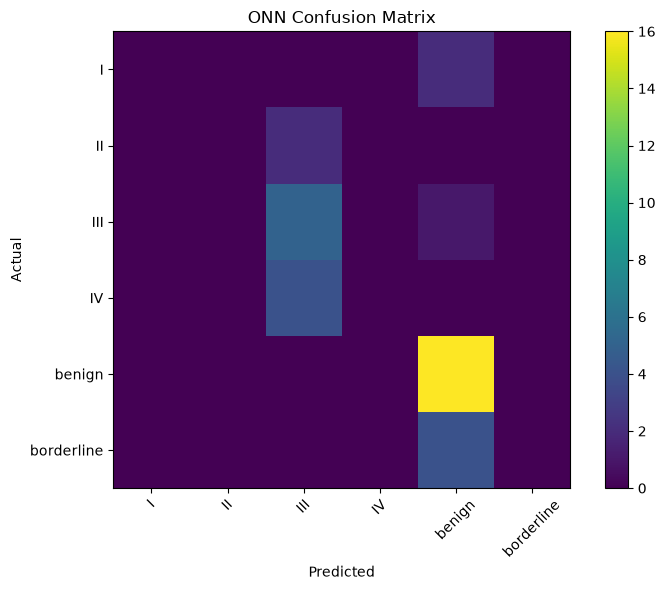

In [62]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

onn_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = onn_model(X_batch)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_targets.extend(
            y_batch.cpu().numpy()
        )


# ============================================================
# TEST ACCURACY
# ============================================================

test_accuracy = (
    np.array(all_predictions) ==
    np.array(all_targets)
).mean()

print(f"Test accuracy: {test_accuracy:.4f}")


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_targets,
    all_predictions
)

print("\nCONFUSION MATRIX\n")
print(cm)


# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("ONN Confusion Matrix")

plt.colorbar()

plt.tight_layout()

plt.show()

In [ ]:
# MODEL

input_size = len(features)
num_classes = len(label_encoder.classes_)

model = MLP(
    input_size=input_size,
    num_classes=num_classes
)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=6, bias=True)
  )
)


In [ ]:
# DEVICE

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = model.to(device)

Device: cpu


In [ ]:
# LOSS & OPT

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

Epoch [10/100] Train Loss: 1.1574 Train Acc: 0.590 Val Loss: 1.1698 Val Acc: 0.588
Epoch [20/100] Train Loss: 1.0201 Train Acc: 0.635 Val Loss: 1.1473 Val Acc: 0.559
Epoch [30/100] Train Loss: 0.9164 Train Acc: 0.654 Val Loss: 1.2032 Val Acc: 0.529
Epoch [40/100] Train Loss: 0.7985 Train Acc: 0.699 Val Loss: 1.2651 Val Acc: 0.588
Epoch [50/100] Train Loss: 0.7400 Train Acc: 0.756 Val Loss: 1.3486 Val Acc: 0.500
Epoch [60/100] Train Loss: 0.7167 Train Acc: 0.756 Val Loss: 1.3784 Val Acc: 0.529
Epoch [70/100] Train Loss: 0.6506 Train Acc: 0.744 Val Loss: 1.4565 Val Acc: 0.529
Epoch [80/100] Train Loss: 0.6486 Train Acc: 0.776 Val Loss: 1.4749 Val Acc: 0.500
Epoch [90/100] Train Loss: 0.6369 Train Acc: 0.756 Val Loss: 1.5471 Val Acc: 0.529
Epoch [100/100] Train Loss: 0.5348 Train Acc: 0.795 Val Loss: 1.6059 Val Acc: 0.529


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

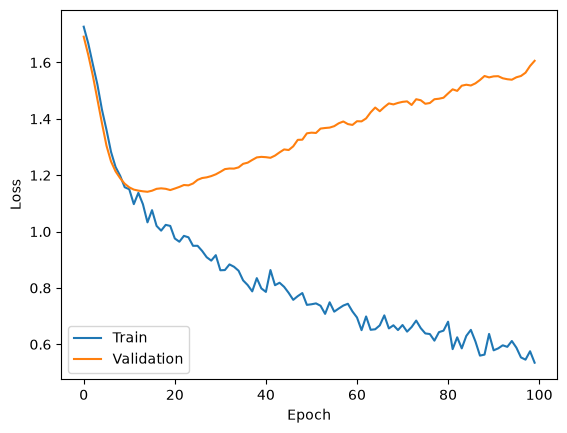

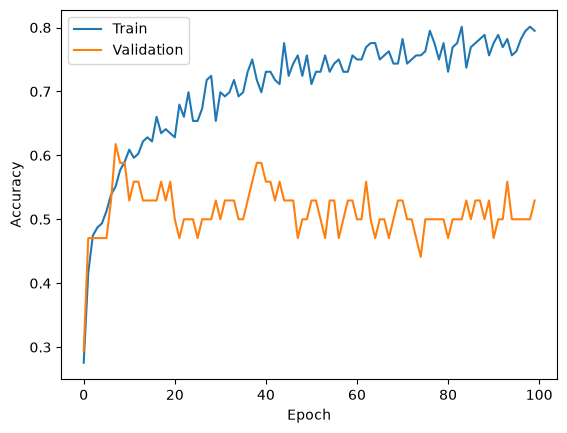

In [ ]:
# TRAINING

num_epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Statistics
        running_loss += loss.item() * X_batch.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total


    # Save statistics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_accuracy:.3f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_accuracy:.3f}"
        )

        plt.figure()

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

plt.figure()

plt.plot(train_accuracies, label="Train")
plt.plot(val_accuracies, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
# EVALUATION

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_targets.extend(
            y_batch.numpy()
        )

test_accuracy = accuracy_score(
    all_targets,
    all_predictions
)

print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.471


              precision    recall  f1-score   support

           I       0.00      0.00      0.00         2
          II       0.00      0.00      0.00         2
         III       0.25      0.33      0.29         6
          IV       0.25      0.25      0.25         4
      benign       0.65      0.81      0.72        16
  borderline       0.00      0.00      0.00         4

    accuracy                           0.47        34
   macro avg       0.19      0.23      0.21        34
weighted avg       0.38      0.47      0.42        34

[[ 0  0  0  0  2  0]
 [ 0  0  2  0  0  0]
 [ 0  0  2  3  1  0]
 [ 0  0  3  1  0  0]
 [ 0  0  1  0 13  2]
 [ 0  0  0  0  4  0]]


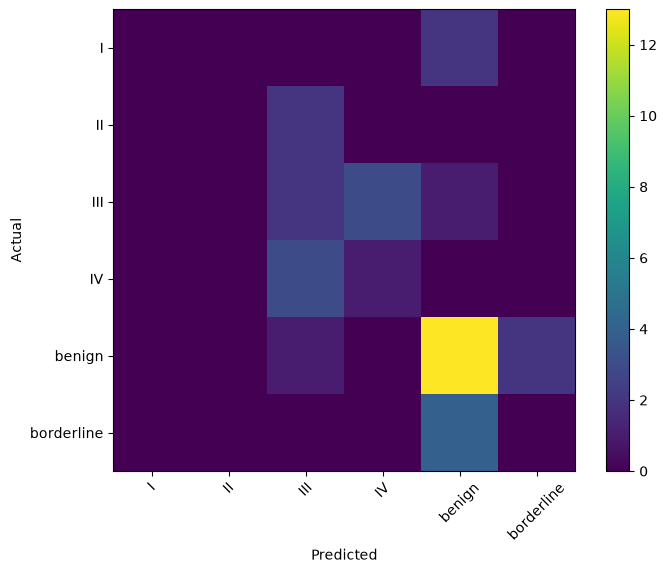

In [ ]:
# CLASSIFICATION REPORT

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

cm = confusion_matrix(
    all_targets,
    all_predictions
)

print(cm)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()